# Insurance Claim Fraud Detection Pipeline

BT5151 Group Project — Fraud Oracle dataset, LangGraph multi-agent pipeline, Gradio UI.

In [1]:
!pip install -q xgboost lightgbm langchain langgraph langchain-openai gradio openai python-dotenv pyyaml

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import gradio as gr
import yaml
import warnings, os, json, time, re

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    roc_curve, f1_score, average_precision_score, accuracy_score,
    roc_auc_score, precision_score, recall_score
)
from typing import TypedDict, Any
from IPython.display import display, Markdown
from dotenv import load_dotenv
from langgraph.graph import StateGraph, END
from openai import OpenAI

warnings.filterwarnings('ignore')
load_dotenv()

# numpy JSON serialisation fix for Gradio
import json as _json
class _NumpyEncoder(_json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer,)): return int(obj)
        if isinstance(obj, (np.floating,)): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)
_json.JSONEncoder.default = _NumpyEncoder.default

# OpenAI client
try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
except Exception:
    OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')
oai_client = OpenAI(api_key=OPENAI_API_KEY)

c:\Users\ngjun\anaconda3\envs\msba\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load SKILL.md files, parse YAML frontmatter from body.

In [3]:
def load_skill(path):
    """Parse a SKILL.md file into {name, description, body}."""
    with open(path) as f:
        raw = f.read()
    if raw.startswith('---'):
        parts = raw.split('---', 2)
        meta = yaml.safe_load(parts[1])
        body = parts[2].strip()
    else:
        meta = {'name': '', 'description': ''}
        body = raw.strip()
    return {
        'name': meta.get('name', ''),
        'description': meta.get('description', ''),
        'body': body
    }

skills = {}
for fname in sorted(os.listdir('skills')):
    if not fname.endswith('.md'):
        continue
    skill = load_skill(f'skills/{fname}')
    skills[fname.replace('.md', '')] = skill
    print(f"  {skill['name']}: {skill['description']}")

print(f"\nLoaded {len(skills)} skills")

  assess-claim-risk: LLM agent explains why the claim was flagged using model output and claim details
  evaluate-models: Compute all metrics across multiple thresholds for each model on held-out test data
  feature-engineering: Engineer 3 new features from encoded data, split into train/val/test, fit scaler
  preprocess-data: Load CSV, drop redundant columns, encode categoricals with proper ordinal/binary/label strategy
  recommend-action: LLM agent prescribes the next step for the claims team based on risk level and claim details
  score-fraud-risk: Score a single claim through the selected model and extract top feature contributions
  select-model: LLM agent selects the best model and threshold by weighing statistical performance and precision-recall tradeoffs
  train-models: Train XGBoost, LightGBM, and Logistic Regression with class weight tuning

Loaded 8 skills


## 1. Agent State

Shared memory that flows between pipeline nodes.

In [4]:
class AgentState(TypedDict, total=False):
    # preprocess
    raw_df: Any
    df: Any
    label_encoders: Any
    cat_cols: Any
    # feature engineering
    X_train: Any
    y_train: Any
    X_val: Any
    y_val: Any
    X_test: Any
    y_test: Any
    X_train_scaled: Any
    X_val_scaled: Any
    X_test_scaled: Any
    feature_cols: Any
    scaler: Any
    train_feature_means: Any
    # training
    models: Any
    best_weight: int
    # evaluation
    results: Any
    results_df: Any
    threshold_analysis: str
    test_probs_all: Any
    best_model_name_f1: str
    best_threshold_f1: float
    # selection (LLM)
    selected_model_name: str
    selected_model: Any
    best_threshold: float
    selection_justification: str
    # inference
    claim: dict
    probability: float
    prediction: int
    feature_contributions: dict
    # downstream (LLM)
    risk_level: str
    risk_explanation: str
    recommended_action: str
    messages: list

## 2. Node Functions

Each function is a LangGraph node that reads from and writes to agent state. Nodes 1-4 are deterministic. Node 5 (select-model) uses the LLM to pick the best model.

In [5]:
def preprocess_data_node(state):
    df = pd.read_csv('data/fraud_oracle.csv')
    print(f"Loaded {len(df):,} claims, fraud rate: {df['FraudFound_P'].mean():.3f}")

    # --- drop useless / redundant columns ---
    drop_cols = [
        'PolicyNumber',       # unique ID
        'Age',                # r=0.97 with AgeOfPolicyHolder, uses 0 for minors
        'PolicyType',         # r=0.86 with VehicleCategory, just Category+BasePolicy glued together
        'WeekOfMonth',        # fraud spread 0.008
        'WeekOfMonthClaimed', # fraud spread 0.011
        'DriverRating',       # fraud spread 0.006, all 4 values ~6%
        'Year',               # only 1994-1996, artifact not a real feature
    ]
    df = df.drop(columns=drop_cols)
    print(f"Dropped {len(drop_cols)} columns")

    # --- fix placeholders ---
    df['DayOfWeekClaimed'] = df['DayOfWeekClaimed'].replace('0', 'Unknown')
    df['MonthClaimed'] = df['MonthClaimed'].replace('0', 'Unknown')

    # --- ordinal encoding (preserve natural order) ---
    ordinal_maps = {
        'AgeOfPolicyHolder': {'16 to 17':0,'18 to 20':1,'21 to 25':2,'26 to 30':3,
                              '31 to 35':4,'36 to 40':5,'41 to 50':6,'51 to 65':7,'over 65':8},
        'AgeOfVehicle':      {'new':0,'2 years':1,'3 years':2,'4 years':3,'5 years':4,
                              '6 years':5,'7 years':6,'more than 7':7},
        'VehiclePrice':      {'less than 20000':0,'20000 to 29000':1,'30000 to 39000':2,
                              '40000 to 59000':3,'60000 to 69000':4,'more than 69000':5},
        'PastNumberOfClaims':{'none':0,'1':1,'2 to 4':2,'more than 4':3},
        'Days_Policy_Accident':{'none':0,'1 to 7':1,'8 to 15':2,'15 to 30':3,'more than 30':4},
        'Days_Policy_Claim': {'none':0,'8 to 15':1,'15 to 30':2,'more than 30':3},
        'NumberOfSuppliments':{'none':0,'1 to 2':1,'3 to 5':2,'more than 5':3},
        'AddressChange_Claim':{'no change':0,'4 to 8 years':1,'2 to 3 years':2,'1 year':3,'under 6 months':4},
        'NumberOfCars':      {'1 vehicle':0,'2 vehicles':1,'3 to 4':2,'5 to 8':3,'more than 8':4},
    }
    for col, mapping in ordinal_maps.items():
        df[col] = df[col].map(mapping)

    # --- binary encoding ---
    binary_maps = {
        'Fault':             {'Third Party': 0, 'Policy Holder': 1},
        'Sex':               {'Female': 0, 'Male': 1},
        'AccidentArea':      {'Urban': 0, 'Rural': 1},
        'PoliceReportFiled': {'Yes': 0, 'No': 1},
        'WitnessPresent':    {'Yes': 0, 'No': 1},
        'AgentType':         {'Internal': 0, 'External': 1},
    }
    for col, mapping in binary_maps.items():
        df[col] = df[col].map(mapping)

    # --- label encode remaining nominals (Make, DayOfWeek, etc.) ---
    cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
    label_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

    # also store the manual mappings so inference can decode
    label_encoders['_ordinal_maps'] = ordinal_maps
    label_encoders['_binary_maps'] = binary_maps

    print(f"Encoded: {len(ordinal_maps)} ordinal, {len(binary_maps)} binary, {len(cat_cols)} label-encoded")
    print(f"Final shape: {df.shape}")
    return {"df": df, "label_encoders": label_encoders, "cat_cols": cat_cols,
            "messages": ["preprocess-data: loaded, cleaned, encoded"]}

In [6]:
def feature_engineering_node(state):
    df = state["df"].copy()

    # --- engineered features ---
    # claim delay: MonthClaimed - Month (longer delay = more suspicious)
    df['claim_delay'] = (df['MonthClaimed'] - df['Month']).clip(lower=0)

    # non-standard deductible: 96% are 400, non-400 has 11.5% fraud vs 5.8%
    df['nonstandard_deductible'] = (df['Deductible'] != 400).astype(int)

    # fault + base policy interaction: PolicyHolder+AllPerils = 15.6% fraud
    df['fault_x_basepolicy'] = df['Fault'] * 10 + df['BasePolicy']

    print(f"Engineered 3 features: claim_delay, nonstandard_deductible, fault_x_basepolicy")

    feature_cols = [c for c in df.columns if c != 'FraudFound_P']
    print(f"Total features: {len(feature_cols)}")

    X = df[feature_cols].values
    y = df['FraudFound_P'].values

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.176, random_state=42, stratify=y_trainval)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    print(f"Features: {len(feature_cols)}")
    print(f"Train: {X_train.shape} ({y_train.mean():.3f} pos) | Val: {X_val.shape} | Test: {X_test.shape}")

    train_feature_means = pd.DataFrame(X_train, columns=feature_cols).mean().to_dict()

    return {"X_train": X_train, "y_train": y_train, "X_val": X_val, "y_val": y_val,
            "X_test": X_test, "y_test": y_test,
            "X_train_scaled": X_train_scaled, "X_val_scaled": X_val_scaled, "X_test_scaled": X_test_scaled,
            "feature_cols": feature_cols, "scaler": scaler, "train_feature_means": train_feature_means,
            "messages": state["messages"] + [f"feature-engineering: {len(feature_cols)} features, 70/15/15 split"]}

In [7]:
def train_models_node(state):
    X_train, y_train = state["X_train"], state["y_train"]
    X_val, y_val = state["X_val"], state["y_val"]
    X_train_scaled = state["X_train_scaled"]

    # weight sweep
    best_f1, best_weight = 0, 1
    for w in [1, 3, 5, 10, 15]:
        m = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.05,
            scale_pos_weight=w, subsample=0.8, colsample_bytree=0.8,
            eval_metric='aucpr', tree_method='hist', verbosity=0)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        vp = m.predict_proba(X_val)[:, 1]
        prec, rec, th = precision_recall_curve(y_val, vp)
        f1 = (2 * prec * rec / (prec + rec + 1e-8)).max()
        print(f"  weight={w:>3d}: F1={f1:.4f}")
        if f1 > best_f1: best_f1, best_weight = f1, w
    print(f"Selected weight: {best_weight}")

    # train 3 models
    xgb_model = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
        scale_pos_weight=best_weight, subsample=0.8, colsample_bytree=0.8,
        eval_metric='aucpr', early_stopping_rounds=20, tree_method='hist', verbosity=0)
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    print(f"XGBoost: {xgb_model.best_iteration} trees")

    lgb_model = lgb.LGBMClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, num_leaves=31,
        scale_pos_weight=best_weight, subsample=0.8, colsample_bytree=0.8,
        metric='binary_logloss', verbosity=-1)
    lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)])
    print(f"LightGBM: {lgb_model.best_iteration_} trees")

    lr_model = LogisticRegression(class_weight={0: 1, 1: best_weight}, solver='saga', max_iter=200, tol=1e-3, verbose=0)
    lr_model.fit(X_train_scaled, y_train)
    print(f"Logistic Regression: done")

    models = {'XGBoost': xgb_model, 'LightGBM': lgb_model, 'Logistic Regression': lr_model}
    return {"models": models, "best_weight": best_weight,
            "messages": state["messages"] + [f"train-models: 3 models, weight={best_weight}"]}

In [8]:
def evaluate_models_node(state):
    models = state["models"]
    X_val, y_val = state["X_val"], state["y_val"]
    X_test, y_test = state["X_test"], state["y_test"]
    X_val_scaled, X_test_scaled = state["X_val_scaled"], state["X_test_scaled"]

    def find_best_threshold(y_true, probs):
        prec, rec, th = precision_recall_curve(y_true, probs)
        f1_arr = 2 * prec * rec / (prec + rec + 1e-8)
        return th[min(f1_arr.argmax(), len(th) - 1)]

    results = {}
    test_probs_all = {}
    for name, model in models.items():
        is_lr = name == 'Logistic Regression'
        vp = model.predict_proba(X_val_scaled if is_lr else X_val)[:, 1]
        tp = model.predict_proba(X_test_scaled if is_lr else X_test)[:, 1]
        test_probs_all[name] = tp
        threshold = find_best_threshold(y_val, vp)
        preds = (tp >= threshold).astype(int)
        results[name] = {
            'threshold': round(threshold, 4),
            'accuracy': round(accuracy_score(y_test, preds), 4),
            'precision': round(precision_score(y_test, preds, zero_division=0), 4),
            'recall': round(recall_score(y_test, preds, zero_division=0), 4),
            'f1': round(f1_score(y_test, preds, zero_division=0), 4),
            'auc_roc': round(roc_auc_score(y_test, tp), 4),
            'pr_auc': round(average_precision_score(y_test, tp), 4)}

    results_df = pd.DataFrame(results).T
    results_df.columns = ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'PR-AUC']
    best_model_name_f1 = results_df['F1'].idxmax()
    best_threshold_f1 = results[best_model_name_f1]['threshold']
    print(results_df.to_string())
    print(f"\nF1-best: {best_model_name_f1} (F1={results[best_model_name_f1]['f1']})")

    # multi-threshold analysis for LLM select-model
    lines = []
    for name in models:
        tp = test_probs_all[name]
        lines.append(f"\n=== {name} ===")
        for t in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
            p_ = (tp >= t).astype(int)
            if p_.sum() == 0: continue
            pr = precision_score(y_test, p_, zero_division=0)
            rc = recall_score(y_test, p_, zero_division=0)
            f1 = f1_score(y_test, p_, zero_division=0)
            n_flag = p_.sum()
            flag_pct = n_flag / len(y_test) * 100
            lines.append(f"  t={t:.2f}: P={pr:.3f} R={rc:.3f} F1={f1:.3f} | flagged={n_flag} ({flag_pct:.1f}% of test)")
    threshold_analysis = "\n".join(lines)

    return {"results": results, "results_df": results_df, "test_probs_all": test_probs_all,
            "threshold_analysis": threshold_analysis,
            "best_model_name_f1": best_model_name_f1, "best_threshold_f1": best_threshold_f1,
            "messages": state["messages"] + ["evaluate-models: metrics computed"]}

In [9]:
def select_model_node(state):
    results_df = state["results_df"]
    threshold_analysis = state["threshold_analysis"]
    models = state["models"]

    skill_spec = skills['select-model']['body']
    prompt = f"""Follow this skill specification:\n{skill_spec}\n\n"
    "Model results at F1-optimal thresholds:\n{results_df.to_string()}\n\n"
    "Detailed threshold analysis (precision, recall, F1 at multiple operating points):\n{threshold_analysis}\n\n"
    "Reply EXACTLY in this format:\n"
    "MODEL: <model name exactly as shown>\n"
    "THRESHOLD: <number>\n"
    "JUSTIFICATION: <3-5 sentences>"""

    try:
        resp = oai_client.chat.completions.create(
            model='gpt-4o-mini', messages=[{'role': 'user', 'content': prompt}],
            temperature=0.2, max_tokens=300)
        llm_output = resp.choices[0].message.content.strip()
        print("LLM response:", llm_output)

        model_match = re.search(r'MODEL:\s*(.+)', llm_output)
        thresh_match = re.search(r'THRESHOLD:\s*([\d.]+)', llm_output)
        justification_match = re.search(r'JUSTIFICATION:\s*(.+)', llm_output, re.DOTALL)

        parsed_model = model_match.group(1).strip() if model_match else None
        parsed_threshold = float(thresh_match.group(1)) if thresh_match else None
        justification = justification_match.group(1).strip() if justification_match else llm_output

        if parsed_model in models and parsed_threshold is not None:
            name, threshold = parsed_model, parsed_threshold
            print(f"\nLLM selected: {name} at threshold {threshold}")
        else:
            raise ValueError(f"Parse failed: model={parsed_model}, threshold={parsed_threshold}")
    except Exception as e:
        print(f"LLM selection failed ({e}), falling back to F1-argmax")
        name = state["best_model_name_f1"]
        threshold = state["best_threshold_f1"]
        justification = f"Fallback: selected {name} by highest F1."

    return {"selected_model_name": name, "selected_model": models[name],
            "best_threshold": threshold, "selection_justification": justification,
            "messages": state["messages"] + [f"select-model: {name} @ {threshold}"]}

### Inference nodes

These run per-claim at inference time. score-fraud-risk is deterministic, assess-claim-risk and recommend-action use the LLM.

In [10]:
def compute_claim_features(claim, feature_cols, label_encoders):
    """Encode a raw claim dict into a feature vector matching training format."""
    ordinal_maps = label_encoders.get('_ordinal_maps', {})
    binary_maps = label_encoders.get('_binary_maps', {})

    feats = {}
    for col in feature_cols:
        val = claim.get(col, None)
        if col in ordinal_maps:
            feats[col] = ordinal_maps[col].get(val, 0)
        elif col in binary_maps:
            feats[col] = binary_maps[col].get(val, 0)
        elif col in label_encoders and hasattr(label_encoders[col], 'classes_'):
            le = label_encoders[col]
            feats[col] = le.transform([val])[0] if val in le.classes_ else 0
        elif col == 'claim_delay':
            # engineered: MonthClaimed - Month (both already encoded as ints in claim)
            m = claim.get('MonthClaimed', 0)
            m0 = claim.get('Month', 0)
            if isinstance(m, str) and 'MonthClaimed' in label_encoders:
                le = label_encoders['MonthClaimed']
                m = le.transform([m])[0] if m in le.classes_ else 0
            if isinstance(m0, str) and 'Month' in label_encoders:
                le = label_encoders['Month']
                m0 = le.transform([m0])[0] if m0 in le.classes_ else 0
            feats[col] = max(0, int(m) - int(m0))
        elif col == 'nonstandard_deductible':
            feats[col] = int(claim.get('Deductible', 400) != 400)
        elif col == 'fault_x_basepolicy':
            f = feats.get('Fault', claim.get('Fault', 0))
            b = feats.get('BasePolicy', claim.get('BasePolicy', 0))
            if isinstance(f, str): f = binary_maps.get('Fault', {}).get(f, 0)
            if isinstance(b, str) and 'BasePolicy' in label_encoders:
                le = label_encoders['BasePolicy']
                b = le.transform([b])[0] if b in le.classes_ else 0
            feats[col] = int(f) * 10 + int(b)
        else:
            try: feats[col] = float(val) if val is not None else 0
            except (ValueError, TypeError): feats[col] = 0
    return np.array([feats[c] for c in feature_cols])

def score_fraud_risk_node(state):
    claim = state["claim"]
    feature_cols = state["feature_cols"]
    feat_vec = compute_claim_features(claim, feature_cols, state["label_encoders"])
    model = state["selected_model"]
    X_input = feat_vec.reshape(1, -1)
    # LR needs scaled features, trees don't
    if state["selected_model_name"] == 'Logistic Regression':
        X_input = state["scaler"].transform(X_input)
    prob = float(model.predict_proba(X_input)[0, 1])
    pred = int(prob >= state["best_threshold"])

    imp = model.feature_importances_ if hasattr(model, 'feature_importances_') else np.abs(model.coef_[0])
    top_idx = np.argsort(imp)[-5:][::-1]
    contribs = {}
    for idx in top_idx:
        fname = feature_cols[idx]
        fval = feat_vec[idx]
        mean_val = state["train_feature_means"][fname]
        contribs[fname] = f"{fval:.2f} ({fval / (mean_val + 1e-8):.1f}x avg)" if mean_val != 0 else f"{fval:.2f}"

    return {"probability": prob, "prediction": pred, "feature_contributions": contribs,
            "messages": state["messages"] + [f"score-fraud-risk: prob={prob:.4f}"]}

In [11]:
def assess_claim_risk_node(state):
    prob = state["probability"]
    threshold = state["best_threshold"]
    if prob > 0.8: risk_level = "CRITICAL"
    elif prob > 0.5: risk_level = "HIGH"
    elif prob >= threshold: risk_level = "MEDIUM"
    else: risk_level = "LOW"

    contrib_text = "\n".join([f"  - {k}: {v}" for k, v in state["feature_contributions"].items()])
    claim_str = json.dumps({k: str(v) for k, v in state["claim"].items()}, indent=2)

    skill_spec = skills['assess-claim-risk']['body']
    prompt = f"""Follow this skill specification:\n{skill_spec}\n\n"
    "Claim: {claim_str}\n"
    "Model confidence: {prob:.4f} (threshold: {threshold})\n"
    "Risk level: {risk_level}\n"
    "Top features:\n{contrib_text}\n\n"
    "Respond with ONLY the plain-text explanation, no JSON, no markdown, no extra formatting."""

    try:
        resp = oai_client.chat.completions.create(model='gpt-4o-mini',
            messages=[{'role': 'user', 'content': prompt}], temperature=0.2, max_tokens=250)
        explanation = resp.choices[0].message.content.strip()
    except Exception as e:
        explanation = f"Risk explanation unavailable ({e}). Confidence: {prob:.4f}"

    return {"risk_level": risk_level, "risk_explanation": explanation,
            "messages": state["messages"] + [f"assess-claim-risk: {risk_level}"]}

In [12]:
def recommend_action_node(state):
    if state["risk_level"] == "LOW":
        return {"recommended_action": "AUTO-APPROVE: No significant fraud indicators. Process for standard settlement.",
                "messages": state["messages"] + ["recommend-action: auto-approve"]}

    contrib_text = "\n".join([f"  - {k}: {v}" for k, v in state["feature_contributions"].items()])
    claim_str = json.dumps({k: str(v) for k, v in state["claim"].items()}, indent=2)

    skill_spec = skills['recommend-action']['body']
    prompt = f"""Follow this skill specification:\n{skill_spec}\n\n"
    "Risk: {state['risk_level']}\n"
    "Explanation: {state['risk_explanation']}\n"
    "Claim: {claim_str}\n"
    "Confidence: {state['probability']:.4f}\n"
    "Indicators:\n{contrib_text}\n\n"
    "Respond with ONLY the plain-text recommendation, no JSON, no markdown."""

    try:
        temp = 0.1 if state["risk_level"] in ("HIGH", "CRITICAL") else 0.3
        resp = oai_client.chat.completions.create(model='gpt-4o-mini',
            messages=[{'role': 'user', 'content': prompt}], temperature=temp, max_tokens=350)
        action = resp.choices[0].message.content.strip()
    except Exception as e:
        action = f"MANUAL REVIEW REQUIRED ({e})."

    return {"recommended_action": action,
            "messages": state["messages"] + [f"recommend-action: {state['risk_level']}"]}

## 3. Compile & Run Training Pipeline

In [13]:
def should_recommend_action(state):
    return "recommend_action" if state.get("risk_level") in ("MEDIUM", "HIGH", "CRITICAL") else END

# full pipeline (training + inference)
workflow = StateGraph(AgentState)
for name, fn in [("preprocess_data", preprocess_data_node), ("feature_engineering", feature_engineering_node),
                 ("train_models", train_models_node), ("evaluate_models", evaluate_models_node),
                 ("select_model", select_model_node)]:
    workflow.add_node(name, fn)
workflow.set_entry_point("preprocess_data")
for a, b in [("preprocess_data","feature_engineering"),("feature_engineering","train_models"),
             ("train_models","evaluate_models"),("evaluate_models","select_model")]:
    workflow.add_edge(a, b)
workflow.add_edge("select_model", END)
training_app = workflow.compile()
print("Training pipeline compiled (5 nodes)")

# inference sub-pipeline
inference_workflow = StateGraph(AgentState)
for name, fn in [("score_fraud_risk", score_fraud_risk_node),
                 ("assess_claim_risk", assess_claim_risk_node),
                 ("recommend_action", recommend_action_node)]:
    inference_workflow.add_node(name, fn)
inference_workflow.set_entry_point("score_fraud_risk")
inference_workflow.add_edge("score_fraud_risk", "assess_claim_risk")
inference_workflow.add_conditional_edges("assess_claim_risk", should_recommend_action,
    {"recommend_action": "recommend_action", END: END})
inference_workflow.add_edge("recommend_action", END)
inference_app = inference_workflow.compile()
print("Inference pipeline compiled (3 nodes)")

Training pipeline compiled (5 nodes)
Inference pipeline compiled (3 nodes)


In [14]:
print("Running training pipeline...\n")
train_state = training_app.invoke({})
print(f"\nPipeline state keys: {sorted(train_state.keys())}")
print(f"Pipeline log: {train_state['messages']}")
print(f"Selected model: {train_state.get('selected_model_name', 'MISSING')}")
print(f"Threshold: {train_state.get('best_threshold', 'MISSING')}")
print(f"Feature cols count: {len(train_state.get('feature_cols', []))}")
print(f"Label encoders keys: {[k for k in train_state.get('label_encoders', {}).keys() if not k.startswith('_')]}")
print(f"\nModel selection justification:\n{train_state.get('selection_justification', 'MISSING')}")

Running training pipeline...

Loaded 15,420 claims, fraud rate: 0.060
Dropped 7 columns
Encoded: 9 ordinal, 6 binary, 8 label-encoded
Final shape: (15420, 26)
Engineered 3 features: claim_delay, nonstandard_deductible, fault_x_basepolicy
Total features: 28
Features: 28
Train: (10800, 28) (0.060 pos) | Val: (2307, 28) | Test: (2313, 28)
  weight=  1: F1=0.2784
  weight=  3: F1=0.2747
  weight=  5: F1=0.2857
  weight= 10: F1=0.2749
  weight= 15: F1=0.2751
Selected weight: 5
XGBoost: 15 trees
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[6]	valid_0's binary_logloss: 0.209222
LightGBM: 6 trees
Logistic Regression: done
                     Threshold  Accuracy  Precision  Recall      F1  AUC-ROC  PR-AUC
XGBoost                 0.3634    0.8664     0.1935  0.3913  0.2590   0.8078  0.2015
LightGBM                0.1555    0.8284     0.1565  0.4275  0.2291   0.7856  0.1537
Logistic Regression     0.3766    0.7998     0.1490  0.5000  0.2296   0

## 4. Evaluation Visualisations

Extract metrics and model artifacts from pipeline state, then render plots.

In [15]:
# extract from pipeline state
results = train_state["results"]
results_df = train_state["results_df"]
test_probs_all = train_state["test_probs_all"]
y_test = train_state["y_test"]
feature_cols = train_state["feature_cols"]
models = train_state["models"]
selected_model = train_state["selected_model"]
best_model_name = train_state["selected_model_name"]
best_threshold = train_state["best_threshold"]
scaler = train_state["scaler"]
best_test_probs = test_probs_all[best_model_name]
best_test_preds = (best_test_probs >= best_threshold).astype(int)

print("=== Model Comparison ===")
print(results_df.to_string())
print(f"\nSelected by LLM: {best_model_name} @ threshold={best_threshold}")

=== Model Comparison ===
                     Threshold  Accuracy  Precision  Recall      F1  AUC-ROC  PR-AUC
XGBoost                 0.3634    0.8664     0.1935  0.3913  0.2590   0.8078  0.2015
LightGBM                0.1555    0.8284     0.1565  0.4275  0.2291   0.7856  0.1537
Logistic Regression     0.3766    0.7998     0.1490  0.5000  0.2296   0.8018  0.1447

Selected by LLM: Logistic Regression @ threshold=0.3


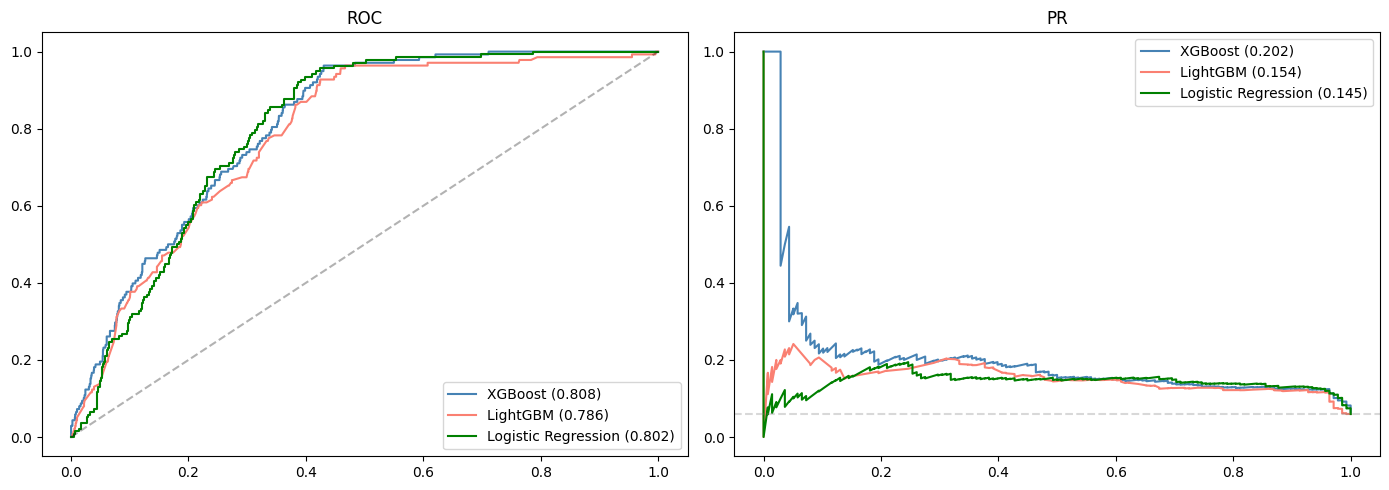

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'XGBoost': 'steelblue', 'LightGBM': 'salmon', 'Logistic Regression': 'green'}
for name in models:
    fpr, tpr, _ = roc_curve(y_test, test_probs_all[name])
    axes[0].plot(fpr, tpr, color=colors[name], label=f'{name} ({results[name]["auc_roc"]:.3f})')
    prec, rec, _ = precision_recall_curve(y_test, test_probs_all[name])
    axes[1].plot(rec, prec, color=colors[name], label=f'{name} ({results[name]["pr_auc"]:.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.3); axes[0].set_title('ROC'); axes[0].legend()
axes[1].axhline(y=y_test.mean(),color='gray',linestyle='--',alpha=0.3); axes[1].set_title('PR'); axes[1].legend()
plt.tight_layout(); plt.show()

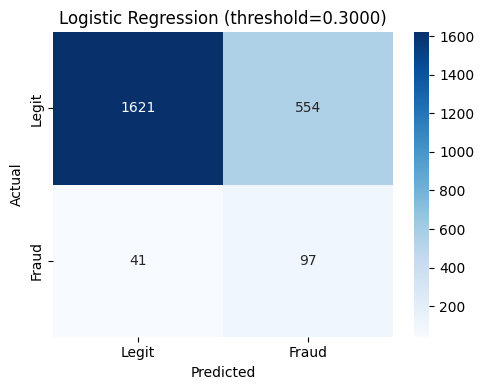

              precision    recall  f1-score   support

       Legit       0.98      0.75      0.84      2175
       Fraud       0.15      0.70      0.25       138

    accuracy                           0.74      2313
   macro avg       0.56      0.72      0.55      2313
weighted avg       0.93      0.74      0.81      2313



In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, best_test_preds), annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'{best_model_name} (threshold={best_threshold:.4f})')
plt.tight_layout(); plt.show()
print(classification_report(y_test, best_test_preds, target_names=['Legit', 'Fraud']))

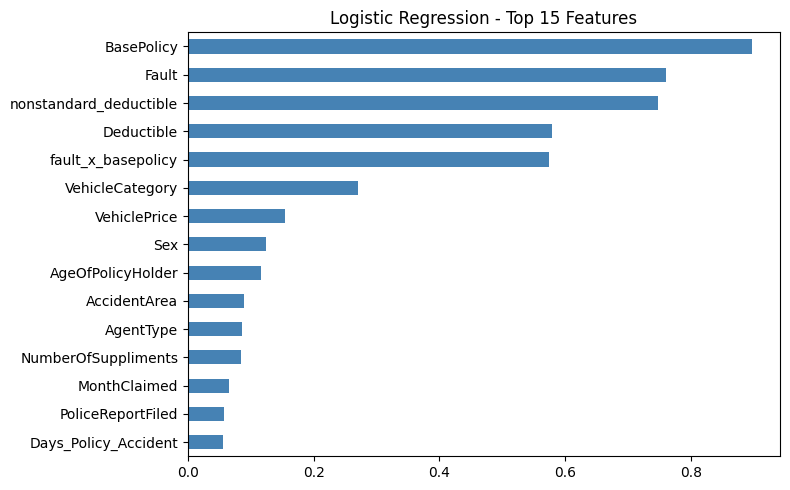

In [18]:
if best_model_name == 'XGBoost': imp = models['XGBoost'].feature_importances_
elif best_model_name == 'LightGBM': imp = models['LightGBM'].feature_importances_
else: imp = np.abs(models['Logistic Regression'].coef_[0])
top15 = pd.Series(imp, index=feature_cols).sort_values().tail(15)
fig, ax = plt.subplots(figsize=(8, 5))
top15.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'{best_model_name} - Top 15 Features'); plt.tight_layout(); plt.show()

## 5. Gradio Dashboard

Three tabs: single claim scoring (with LLM risk assessment + recommended action), batch CSV upload, and threshold explorer.

In [19]:
# prepare inference state (carried from training)
inference_base_state = {
    "selected_model": train_state["selected_model"],
    "selected_model_name": train_state["selected_model_name"],
    "best_threshold": train_state["best_threshold"],
    "feature_cols": train_state["feature_cols"],
    "label_encoders": train_state["label_encoders"],
    "train_feature_means": train_state["train_feature_means"],
    "scaler": train_state["scaler"],
    "messages": [],
}

label_encoders = train_state["label_encoders"]

# demo claims
X_test = train_state["X_test"]
_fraud_idx = np.where(y_test == 1)[0]
_legit_idx = np.where(y_test == 0)[0]
_fraud_best = _fraud_idx[np.argmax(best_test_probs[_fraud_idx])]
_legit_best = _legit_idx[np.argmin(best_test_probs[_legit_idx])]

ordinal_maps = label_encoders.get('_ordinal_maps', {})
binary_maps = label_encoders.get('_binary_maps', {})

def decode_row(row):
    """Decode an encoded feature vector back to original string values."""
    d = {}
    for i, col in enumerate(feature_cols):
        val = row[i]
        if col in ordinal_maps:
            inv = {v: k for k, v in ordinal_maps[col].items()}
            d[col] = inv.get(int(val), str(val))
        elif col in binary_maps:
            inv = {v: k for k, v in binary_maps[col].items()}
            d[col] = inv.get(int(val), str(val))
        elif col in label_encoders and hasattr(label_encoders[col], 'classes_'):
            le = label_encoders[col]
            iv = int(val)
            d[col] = le.inverse_transform([iv])[0] if iv < len(le.classes_) else str(iv)
        else:
            d[col] = float(val)
    return d

DEMO_FRAUD = decode_row(X_test[_fraud_best])
DEMO_LEGIT = decode_row(X_test[_legit_best])

# build dropdown options from all encoding sources
dropdown_options = {}
for col in ordinal_maps:
    dropdown_options[col] = list(ordinal_maps[col].keys())
for col in binary_maps:
    dropdown_options[col] = list(binary_maps[col].keys())
for col, le in label_encoders.items():
    if hasattr(le, 'classes_'):
        dropdown_options[col] = sorted(le.classes_.tolist())

# user-facing input fields (excludes engineered features which are computed)
FIELD_ORDER = [
    'Month', 'DayOfWeek', 'Make', 'AccidentArea',
    'DayOfWeekClaimed', 'MonthClaimed',
    'Sex', 'MaritalStatus', 'Fault',
    'VehicleCategory', 'VehiclePrice',
    'RepNumber', 'Deductible',
    'Days_Policy_Accident', 'Days_Policy_Claim',
    'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
    'PoliceReportFiled', 'WitnessPresent', 'AgentType',
    'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
    'BasePolicy',
]

def score_single_claim(*args):
    claim = {}
    for field, val in zip(FIELD_ORDER, args):
        if field in ['RepNumber', 'Deductible']:
            claim[field] = int(val)
        else:
            claim[field] = val
    state = {**inference_base_state, "claim": claim}
    result = inference_app.invoke(state)
    prob = float(result['probability'])
    risk = str(result['risk_level'])
    explanation = str(result.get('risk_explanation', ''))
    action = str(result.get('recommended_action', 'No action required.'))
    contribs = result.get('feature_contributions', {})

    colors = {'LOW': '#16a34a', 'MEDIUM': '#ca8a04', 'HIGH': '#dc2626', 'CRITICAL': '#7f1d1d'}
    bg = colors.get(risk, '#6b7280')

    summary = (f"{claim.get('AgeOfPolicyHolder','?')} {claim.get('Sex','?')}, {claim.get('MaritalStatus','?')} "
              f"&bull; {claim.get('Make','?')} {claim.get('VehicleCategory','')} "
              f"&bull; Fault: {claim.get('Fault','')} &bull; {claim.get('BasePolicy','')}")
    details = (f"Police: {claim.get('PoliceReportFiled','?')} &bull; "
              f"Witness: {claim.get('WitnessPresent','?')} &bull; "
              f"Past claims: {claim.get('PastNumberOfClaims','?')} &bull; "
              f"Vehicle age: {claim.get('AgeOfVehicle','?')}")

    chips = ' '.join(f'<code>{k}: {v}</code>' for k, v in contribs.items())

    S = '<style>'\
        '.rc{font-family:system-ui,sans-serif!important;max-width:680px;margin:0 auto;background:#ffffff!important;padding:16px;border-radius:12px;color:#1f2937!important}'\
        '.rc *{color:#1f2937!important}'\
        '.rc-badge{padding:18px;border-radius:10px;text-align:center;margin-bottom:14px}'\
        '.rc-badge,.rc-badge *{color:#ffffff!important}'\
        '.rc-badge h2{margin:0;font-size:24px;font-weight:700}'\
        '.rc-badge p{margin:4px 0 0;font-size:14px;opacity:.85}'\
        '.rc-card{padding:14px;border-radius:8px;margin-bottom:10px;border:1px solid #d1d5db!important;background:#ffffff!important}'\
        '.rc-card h3{margin:0 0 6px;font-size:12px;color:#6b7280!important;text-transform:uppercase;letter-spacing:.5px;font-weight:600}'\
        '.rc-card p{margin:0;line-height:1.6;font-size:14px}'\
        '.rc-card code{background:#e5e7eb!important;padding:2px 7px;border-radius:4px;font-size:12px;white-space:nowrap;display:inline-block;margin:2px}'\
        '.rc-muted,.rc-muted *{font-size:12px!important;color:#9ca3af!important}'\
        '.rc-action{border-left:3px solid;padding-left:14px;background:#f9fafb!important}'\
        '.rc-claim{background:#f3f4f6!important}'\
        '</style>'

    report = f'''{S}
    <div class="rc">
      <div class="rc-badge" style="background:{bg}">
        <h2>{risk}</h2>
        <p>Confidence: {prob:.1%}</p>
      </div>
      <div class="rc-card rc-claim">
        <h3>Claim</h3>
        <p>{summary}</p>
        <p class="rc-muted">{details}</p>
      </div>
      <div class="rc-card">
        <h3>Risk Assessment</h3>
        <p>{explanation}</p>
      </div>
      <div class="rc-card">
        <h3>Key Indicators</h3>
        <p>{chips}</p>
      </div>
      <div class="rc-card rc-action" style="border-color:{bg}">
        <h3>Recommended Action</h3>
        <p>{action}</p>
      </div>
    </div>'''
    return report

def load_demo(d): return tuple(d[f] for f in FIELD_ORDER)

def score_batch(file):
    try: batch_df = pd.read_csv(file.name)
    except Exception as e: return None, f"Error: {e}"
    fc, le = train_state["feature_cols"], train_state["label_encoders"]
    rows = []
    for _, row in batch_df.iterrows():
        fv = compute_claim_features(row.to_dict(), fc, le)
        X_in = fv.reshape(1,-1)
        if best_model_name == 'Logistic Regression': X_in = scaler.transform(X_in)
        prob = float(selected_model.predict_proba(X_in)[0,1])
        pred = int(prob >= best_threshold)
        risk = "CRITICAL" if pred and prob>0.8 else "HIGH" if pred and prob>0.5 else "MEDIUM" if pred else "LOW"
        rows.append({'Make': str(row.get('Make','')), 'Fault': str(row.get('Fault','')),
                     'VehicleCategory': str(row.get('VehicleCategory','')),
                     'Probability': round(prob,4), 'Risk': risk})
    out = pd.DataFrame(rows)
    return out, f"{len(out)} claims, {(out['Risk']!='LOW').sum()} flagged"

def explore_threshold(threshold):
    preds = (best_test_probs >= threshold).astype(int)
    if preds.sum() == 0: return "No claims flagged at this threshold."
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f1 = 2*p*r/(p+r+1e-8)
    tn,fp,fn,tp = confusion_matrix(y_test, preds).ravel()
    flag_pct = preds.mean() * 100
    return f"""### Threshold: {threshold:.3f}\n"
    "| Metric | Value |\n|---|---|\n"
    "| Precision | {p:.1%} |\n| Recall | {r:.1%} |\n| F1 | {f1:.3f} |\n"
    "| True Positives | {tp} |\n| False Positives | {fp} |\n| Missed Fraud | {fn} |\n"
    "| Flagged | {preds.sum()} ({flag_pct:.1f}% of test set) |\n\n"
    "{f'At this threshold, **{p:.0%}** of flagged claims are true fraud, catching **{r:.0%}** of all fraud.'}"""

with gr.Blocks(title="Fraud Detection", theme=gr.themes.Soft()) as demo:
    gr.Markdown(f"# Insurance Claim Fraud Detection\n**{best_model_name}** (selected by LLM) | threshold={best_threshold:.4f}")
    with gr.Tab("Single Claim"):
        with gr.Row():
            fraud_btn = gr.Button("Load Fraud Demo", variant="secondary")
            legit_btn = gr.Button("Load Legit Demo", variant="secondary")
        inputs = []
        with gr.Row():
            inputs.append(gr.Dropdown(dropdown_options['Month'], label="Month", value="Jan"))
            inputs.append(gr.Dropdown(dropdown_options['DayOfWeek'], label="DayOfWeek", value="Monday"))
            inputs.append(gr.Dropdown(dropdown_options['Make'], label="Make", value="Honda"))
            inputs.append(gr.Dropdown(dropdown_options['AccidentArea'], label="AccidentArea", value="Urban"))
        with gr.Row():
            inputs.append(gr.Dropdown(dropdown_options['DayOfWeekClaimed'], label="DayClaimed", value="Monday"))
            inputs.append(gr.Dropdown(dropdown_options['MonthClaimed'], label="MonthClaimed", value="Jan"))
            inputs.append(gr.Dropdown(dropdown_options['Sex'], label="Sex", value="Male"))
            inputs.append(gr.Dropdown(dropdown_options['MaritalStatus'], label="MaritalStatus", value="Single"))
        with gr.Row():
            inputs.append(gr.Dropdown(dropdown_options['Fault'], label="Fault", value="Policy Holder"))
            inputs.append(gr.Dropdown(dropdown_options['VehicleCategory'], label="VehicleCategory", value="Sedan"))
            inputs.append(gr.Dropdown(dropdown_options['VehiclePrice'], label="VehiclePrice", value="20000 to 29000"))
            inputs.append(gr.Number(label="RepNumber", value=1, minimum=1, maximum=16))
        with gr.Row():
            inputs.append(gr.Dropdown([300,400,500,700], label="Deductible", value=400))
            inputs.append(gr.Dropdown(dropdown_options['Days_Policy_Accident'], label="DaysPolicyAccident", value="more than 30"))
            inputs.append(gr.Dropdown(dropdown_options['Days_Policy_Claim'], label="DaysPolicyClaim", value="more than 30"))
            inputs.append(gr.Dropdown(dropdown_options['PastNumberOfClaims'], label="PastClaims", value="none"))
        with gr.Row():
            inputs.append(gr.Dropdown(dropdown_options['AgeOfVehicle'], label="AgeOfVehicle", value="3 years"))
            inputs.append(gr.Dropdown(dropdown_options['AgeOfPolicyHolder'], label="AgeOfHolder", value="26 to 30"))
            inputs.append(gr.Dropdown(dropdown_options['PoliceReportFiled'], label="PoliceReport", value="No"))
            inputs.append(gr.Dropdown(dropdown_options['WitnessPresent'], label="Witness", value="No"))
        with gr.Row():
            inputs.append(gr.Dropdown(dropdown_options['AgentType'], label="AgentType", value="External"))
            inputs.append(gr.Dropdown(dropdown_options['NumberOfSuppliments'], label="Suppliments", value="none"))
            inputs.append(gr.Dropdown(dropdown_options['AddressChange_Claim'], label="AddressChange", value="no change"))
            inputs.append(gr.Dropdown(dropdown_options['NumberOfCars'], label="NumCars", value="1 vehicle"))
        with gr.Row():
            inputs.append(gr.Dropdown(dropdown_options['BasePolicy'], label="BasePolicy", value="Collision"))
        score_btn = gr.Button("Score Claim", variant="primary")
        report_html = gr.HTML(value="<div style='padding:40px;text-align:center;color:#9ca3af;font-family:system-ui,sans-serif'>Submit a claim or load a demo to begin</div>")
        fraud_btn.click(lambda: load_demo(DEMO_FRAUD), outputs=inputs)
        legit_btn.click(lambda: load_demo(DEMO_LEGIT), outputs=inputs)
        score_btn.click(score_single_claim, inputs=inputs, outputs=[report_html])
    with gr.Tab("Batch Upload"):
        file_input = gr.File(label="Upload CSV")
        batch_btn = gr.Button("Score Batch", variant="primary")
        batch_table = gr.Dataframe(label="Results")
        batch_summary = gr.Textbox(label="Summary", interactive=False)
        batch_btn.click(score_batch, inputs=[file_input], outputs=[batch_table, batch_summary])
    with gr.Tab("Threshold Explorer"):
        gr.Markdown("Adjust the threshold to see how it affects precision, recall, and business cost.")
        threshold_slider = gr.Slider(0.01, 0.95, value=float(best_threshold), step=0.01, label="Probability Threshold")
        threshold_output = gr.Markdown()
        threshold_slider.change(explore_threshold, inputs=[threshold_slider], outputs=[threshold_output])
print("Dashboard built")

Dashboard built


In [20]:
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://153f7ce8918d75c344.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 6. End-to-End Tests

Four test cases: known fraud, known legit, suspicious synthetic profile, safe synthetic profile.

In [21]:
def run_test(name, claim):
    state = {**inference_base_state, "claim": claim}
    r = inference_app.invoke(state)
    print(f"{name}: prob={r['probability']:.4f}, risk={r['risk_level']}")
    print(f"  Explanation: {r.get('risk_explanation','')[:120]}...")
    print(f"  Action: {r.get('recommended_action','')[:120]}...")
    return r

r1 = run_test("Test 1 (fraud)", DEMO_FRAUD)
r2 = run_test("Test 2 (legit)", DEMO_LEGIT)

assert r1['probability'] > r2['probability'], f"Fraud ({r1['probability']:.4f}) should score higher than legit ({r2['probability']:.4f})"
print(f"\nFraud prob ({r1['probability']:.4f}) > Legit prob ({r2['probability']:.4f}): PASS")

Test 1 (fraud): prob=0.8378, risk=CRITICAL
  Explanation: This claim has been assessed as CRITICAL risk due to several concerning factors. The policyholder's fault in the acciden...
  Action: Escalate this claim to the Special Investigations Unit (SIU) due to its CRITICAL risk level. Immediate actions should in...
Test 2 (legit): prob=0.0015, risk=LOW
  Explanation: The risk level for this claim is LOW. The model's confidence is very low at 0.0015, which is well below the threshold of...
  Action: ...

Fraud prob (0.8378) > Legit prob (0.0015): PASS


In [22]:
r3 = run_test("Test 3 (suspicious)", {
    'Month': 'Jan', 'DayOfWeek': 'Monday',
    'Make': 'Ferrari', 'AccidentArea': 'Rural',
    'DayOfWeekClaimed': 'Friday', 'MonthClaimed': 'Feb',
    'Sex': 'Male', 'MaritalStatus': 'Single', 'Fault': 'Policy Holder',
    'VehicleCategory': 'Sport', 'VehiclePrice': 'more than 69000',
    'RepNumber': 1, 'Deductible': 300,
    'Days_Policy_Accident': '1 to 7', 'Days_Policy_Claim': '8 to 15',
    'PastNumberOfClaims': '2 to 4', 'AgeOfVehicle': 'new',
    'AgeOfPolicyHolder': '18 to 20',
    'PoliceReportFiled': 'No', 'WitnessPresent': 'No', 'AgentType': 'External',
    'NumberOfSuppliments': '3 to 5', 'AddressChange_Claim': 'under 6 months',
    'NumberOfCars': '1 vehicle', 'BasePolicy': 'All Perils'})

r4 = run_test("Test 4 (safe)", {
    'Month': 'Jun', 'DayOfWeek': 'Wednesday',
    'Make': 'Toyota', 'AccidentArea': 'Urban',
    'DayOfWeekClaimed': 'Thursday', 'MonthClaimed': 'Jun',
    'Sex': 'Female', 'MaritalStatus': 'Married', 'Fault': 'Third Party',
    'VehicleCategory': 'Sedan', 'VehiclePrice': '20000 to 29000',
    'RepNumber': 8, 'Deductible': 500,
    'Days_Policy_Accident': 'more than 30', 'Days_Policy_Claim': 'more than 30',
    'PastNumberOfClaims': 'none', 'AgeOfVehicle': '5 years',
    'AgeOfPolicyHolder': '51 to 65',
    'PoliceReportFiled': 'Yes', 'WitnessPresent': 'Yes', 'AgentType': 'Internal',
    'NumberOfSuppliments': 'none', 'AddressChange_Claim': 'no change',
    'NumberOfCars': '2 vehicles', 'BasePolicy': 'Collision'})

Test 3 (suspicious): prob=0.9994, risk=CRITICAL
  Explanation: This claim has been assessed as CRITICAL risk due to several concerning factors. The policyholder is at fault for the ac...
  Action: Escalate this claim immediately due to its CRITICAL risk level. Freeze the claim payment and recommend a field investiga...
Test 4 (safe): prob=0.0625, risk=LOW
  Explanation: The risk level for this claim is LOW. The model's confidence is low at 0.0625, which is below the threshold of 0.3. Key ...
  Action: ...
